Loaded X_stratified from /edata/obdw/sandwich_analysis_data/X_basic_plus_clin_sdh_location_stratified.csv
DESCRIPTIVE WER STATISTICS BY DEMOGRAPHICS

Analyzing 2859 participants with valid WER data
Overall WER: Mean=24.839, Median=17.628, SD=133.154

1. WER BY RACE

WER Statistics by Race:
                        Count    Mean  Median       SD    Min       Max  \
race_category                                                             
Asian                     105  30.550  27.621   23.974  0.000   144.444   
Black/African American     15  18.964  15.909   10.382  7.759    43.827   
Multiple Races            397  19.659  13.636   26.235  0.000   408.333   
Not specified              13  18.439  18.681   13.469  1.852    39.130   
Race 1.0                 1851  20.037  16.348   37.090  0.000  1350.000   
White                     478  46.842  25.206  315.571  0.000  6866.667   

                            Q1      Q3  
race_category                           
Asian                   15

/tmp/ipykernel_969839/1391057726.py:197: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=wer_data, y='race_category', x='wer',
/tmp/ipykernel_969839/1391057726.py:227: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=wer_data, y='age_category', x='wer',
/tmp/ipykernel_969839/1391057726.py:257: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=wer_data, y='gender_category', x='wer',


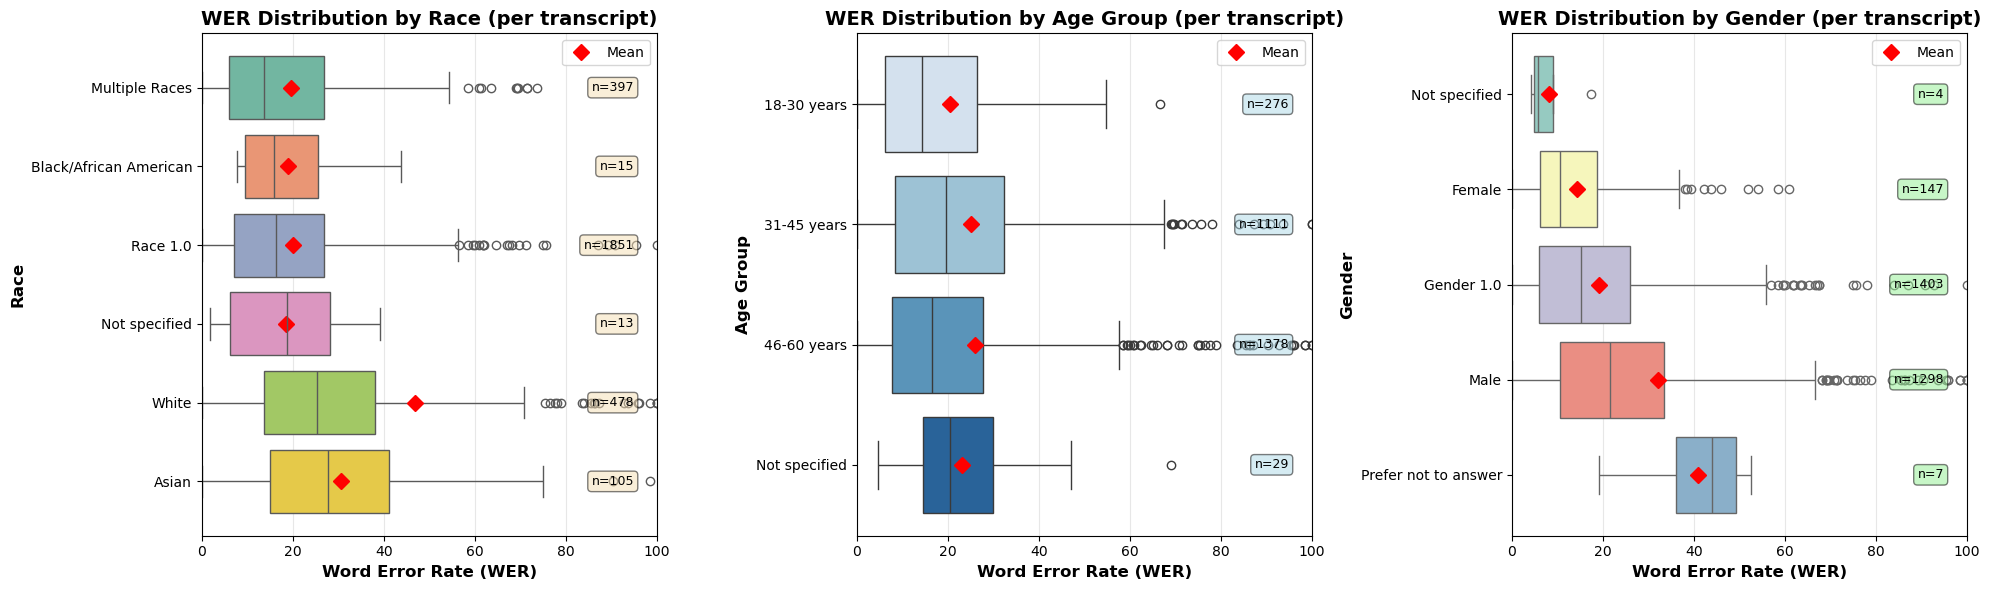


Saved: /edata/obdw/sandwich_analysis_data/wer_by_demographics_boxplots.png

STATISTICAL TESTS FOR GROUP DIFFERENCES

MULTIPLE HYPOTHESIS CORRECTION APPLIED (4 tests)

Bonferroni-corrected α = 0.0125 (0.05 / 4 tests)
FDR-corrected α = 0.0125

  Test  H-statistic  p-value (uncorrected)  p-value (Bonferroni)  Significant (Bonferroni)  p-value (FDR)  Significant (FDR)
  Race   151.147596           7.607261e-31          3.042905e-30                      True   1.014302e-30               True
   Age    29.653219           5.758021e-06          2.303209e-05                      True   5.758021e-06               True
Gender   164.113218           1.917086e-34          7.668345e-34                      True   3.834173e-34               True
Gender   164.113218           1.917086e-34          7.668345e-34                      True   3.834173e-34               True

Saved: /edata/obdw/sandwich_analysis_data/wer_demographic_tests_with_correction.csv

INDIVIDUAL TEST RESULTS

Race:
  H-statistic: 

In [1]:
# ===============================================================================
# DESCRIPTIVE WER STRATIFIED BY KEY DEMOGRAPHICS
# ===============================================================================


import pandas as pd
from pathlib import Path

if "X_stratified" not in globals():
    csv_path = Path("/edata/obdw/sandwich_analysis_data/X_basic_plus_clin_sdh_location_stratified.csv")
    X_stratified = pd.read_csv(csv_path)
    print(f"Loaded X_stratified from {csv_path}")
else:
    print("X_stratified already exists in memory")

out_folder = "/edata/obdw/sandwich_analysis_data/"

if 'X_stratified' in locals():
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    
    print("="*80)
    print("DESCRIPTIVE WER STATISTICS BY DEMOGRAPHICS")
    print("="*80)
    
    # Check if WER column exists
    if 'wer' not in X_stratified.columns:
        print("WARNING: 'wer' column not found in X_stratified")
    else:
        # Remove rows with missing WER values
        wer_data = X_stratified[X_stratified['wer'].notna()].copy()
        
        print(f"\nAnalyzing {len(wer_data)} participants with valid WER data")
        print(f"Overall WER: Mean={wer_data['wer'].mean():.3f}, Median={wer_data['wer'].median():.3f}, SD={wer_data['wer'].std():.3f}")
        
        # -----------------------------------------------------------------------
        # 1. WER BY RACE
        # -----------------------------------------------------------------------
        print("\n" + "="*80)
        print("1. WER BY RACE")
        print("="*80)
        
        # Get race columns and decode
        race_cols = [col for col in wer_data.columns if col.startswith('race_')]
        
        if race_cols:
            # Create race category from one-hot encoding
            def get_race_category(row):
                for col in race_cols:
                    if row[col] == 1:
                        race_code = col.replace('race_', '')
                        race_map = {
                            '2.0': 'White',
                            '4.0': 'Black/African American', 
                            '5.0': 'Asian',
                            '6.0': 'Multiple Races',
                            '999.0': 'Prefer not to answer'
                        }
                        return race_map.get(race_code, f'Race {race_code}')
                return 'Not specified'
            
            wer_data['race_category'] = wer_data.apply(get_race_category, axis=1)
            
            # Calculate statistics by race
            race_stats = wer_data.groupby('race_category')['wer'].agg([
                ('Count', 'count'),
                ('Mean', 'mean'),
                ('Median', 'median'),
                ('SD', 'std'),
                ('Min', 'min'),
                ('Max', 'max'),
                ('Q1', lambda x: x.quantile(0.25)),
                ('Q3', lambda x: x.quantile(0.75))
            ]).round(3)
            
            print("\nWER Statistics by Race:")
            print(race_stats)
            
            # Save to CSV
            race_stats.to_csv(out_folder + "wer_by_race_descriptives.csv")
            print(f"\nSaved: {out_folder}wer_by_race_descriptives.csv")
        
        # -----------------------------------------------------------------------
        # 2. WER BY AGE BIN
        # -----------------------------------------------------------------------
        print("\n" + "="*80)
        print("2. WER BY AGE BIN")
        print("="*80)
        
        # Get age columns and decode
        age_cols = [col for col in wer_data.columns if col.startswith('binned_age_')]
        
        if age_cols:
            # Create age category from one-hot encoding
            def get_age_category(row):
                for col in age_cols:
                    if row[col] == 1:
                        age_code = col.replace('binned_age_', '').replace('.0', '')
                        age_map = {
                            '1': '18-30 years',
                            '2': '31-45 years',
                            '3': '46-60 years',
                            '4': '61+ years'
                        }
                        return age_map.get(age_code, f'Age bin {age_code}')
                return 'Not specified'
            
            wer_data['age_category'] = wer_data.apply(get_age_category, axis=1)
            
            # Calculate statistics by age
            age_stats = wer_data.groupby('age_category')['wer'].agg([
                ('Count', 'count'),
                ('Mean', 'mean'),
                ('Median', 'median'),
                ('SD', 'std'),
                ('Min', 'min'),
                ('Max', 'max'),
                ('Q1', lambda x: x.quantile(0.25)),
                ('Q3', lambda x: x.quantile(0.75))
            ]).round(3)
            
            # Reorder by age
            age_order = ['18-30 years', '31-45 years', '46-60 years', '61+ years', 'Not specified']
            age_stats = age_stats.reindex([cat for cat in age_order if cat in age_stats.index])
            
            print("\nWER Statistics by Age Group:")
            print(age_stats)
            
            # Save to CSV
            age_stats.to_csv(out_folder + "wer_by_age_descriptives.csv")
            print(f"\nSaved: {out_folder}wer_by_age_descriptives.csv")
        
        # -----------------------------------------------------------------------
        # 3. WER BY GENDER
        # -----------------------------------------------------------------------
        print("\n" + "="*80)
        print("3. WER BY GENDER")
        print("="*80)
        
        # Get gender columns and decode
        gender_cols = [col for col in wer_data.columns if col.startswith('gender_')]
        
        if gender_cols:
            # Create gender category from one-hot encoding
            def get_gender_category(row):
                for col in gender_cols:
                    if row[col] == 1:
                        gender_code = col.replace('gender_', '')
                        gender_map = {
                            '2.0': 'Male',
                            '3.0': 'Female',
                            '4.0': 'Non-binary/Other',
                            '5.0': 'Prefer not to answer'
                        }
                        return gender_map.get(gender_code, f'Gender {gender_code}')
                return 'Not specified'
            
            #ToDo: change to use the AVGH decodeing function instead of hardcoding the map here
            wer_data['gender_category'] = wer_data.apply(get_gender_category, axis=1)
            
            # Calculate statistics by gender
            gender_stats = wer_data.groupby('gender_category')['wer'].agg([
                ('Count', 'count'),
                ('Mean', 'mean'),
                ('Median', 'median'),
                ('SD', 'std'),
                ('Min', 'min'),
                ('Max', 'max'),
                ('Q1', lambda x: x.quantile(0.25)),
                ('Q3', lambda x: x.quantile(0.75))
            ]).round(3)
            
            print("\nWER Statistics by Gender:")
            print(gender_stats)
            
            # Save to CSV
            gender_stats.to_csv(out_folder + "wer_by_gender_descriptives.csv")
            print(f"\nSaved: {out_folder}wer_by_gender_descriptives.csv")
        
        # -----------------------------------------------------------------------
        # VISUALIZATIONS: BOXPLOTS
        # -----------------------------------------------------------------------
        print("\n" + "="*80)
        print("CREATING WER BOXPLOT VISUALIZATIONS")
        print("="*80)
        
        fig, axes = plt.subplots(1, 3, figsize=(20, 6))
        
        # Plot 1: WER by Race
        if 'race_category' in wer_data.columns:
            ax = axes[0]
            
            # Sort by median WER
            race_order = wer_data.groupby('race_category')['wer'].median().sort_values().index
            
            sns.boxplot(data=wer_data, y='race_category', x='wer', 
                       order=race_order, ax=ax, palette='Set2')
            
            # Add mean markers
            means = wer_data.groupby('race_category')['wer'].mean()
            for i, race in enumerate(race_order):
                ax.plot(means[race], i, 'D', markersize=8, color='red', 
                       label='Mean' if i == 0 else '')
            
            ax.set_xlabel('Word Error Rate (WER)', fontsize=12, fontweight='bold')
            ax.set_ylabel('Race', fontsize=12, fontweight='bold')
            ax.set_title('WER Distribution by Race (per transcript)', fontsize=14, fontweight='bold')
            ax.set_xlim(0, 100)
            ax.legend()
            ax.grid(True, alpha=0.3, axis='x')
            
            # Add sample sizes
            for i, race in enumerate(race_order):
                count = len(wer_data[wer_data['race_category'] == race])
                ax.text(ax.get_xlim()[1] * 0.95, i, f'n={count}', 
                       ha='right', va='center', fontsize=9, 
                       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        # Plot 2: WER by Age
        if 'age_category' in wer_data.columns:
            ax = axes[1]
            
            # Use predefined age order
            age_order_plot = [cat for cat in age_order if cat in wer_data['age_category'].unique()]
            
            sns.boxplot(data=wer_data, y='age_category', x='wer',
                       order=age_order_plot, ax=ax, palette='Blues')
            
            # Add mean markers
            means = wer_data.groupby('age_category')['wer'].mean()
            for i, age in enumerate(age_order_plot):
                ax.plot(means[age], i, 'D', markersize=8, color='red',
                       label='Mean' if i == 0 else '')
            
            ax.set_xlabel('Word Error Rate (WER)', fontsize=12, fontweight='bold')
            ax.set_ylabel('Age Group', fontsize=12, fontweight='bold')
            ax.set_title('WER Distribution by Age Group (per transcript)', fontsize=14, fontweight='bold')
            ax.set_xlim(0, 100)
            ax.legend()
            ax.grid(True, alpha=0.3, axis='x')
            
            # Add sample sizes
            for i, age in enumerate(age_order_plot):
                count = len(wer_data[wer_data['age_category'] == age])
                ax.text(ax.get_xlim()[1] * 0.95, i, f'n={count}',
                       ha='right', va='center', fontsize=9,
                       bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
        
        # Plot 3: WER by Gender
        if 'gender_category' in wer_data.columns:
            ax = axes[2]
            
            # Sort by median WER
            gender_order = wer_data.groupby('gender_category')['wer'].median().sort_values().index
            
            sns.boxplot(data=wer_data, y='gender_category', x='wer',
                       order=gender_order, ax=ax, palette='Set3')
            
            # Add mean markers
            means = wer_data.groupby('gender_category')['wer'].mean()
            for i, gender in enumerate(gender_order):
                ax.plot(means[gender], i, 'D', markersize=8, color='red',
                       label='Mean' if i == 0 else '')
            
            ax.set_xlabel('Word Error Rate (WER)', fontsize=12, fontweight='bold')
            ax.set_ylabel('Gender', fontsize=12, fontweight='bold')
            ax.set_title('WER Distribution by Gender (per transcript)', fontsize=14, fontweight='bold')
            ax.set_xlim(0, 100)
            ax.legend()
            ax.grid(True, alpha=0.3, axis='x')
            
            # Add sample sizes
            for i, gender in enumerate(gender_order):
                count = len(wer_data[wer_data['gender_category'] == gender])
                ax.text(ax.get_xlim()[1] * 0.95, i, f'n={count}',
                       ha='right', va='center', fontsize=9,
                       bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
        
        plt.tight_layout()
        plt.savefig(out_folder + "wer_by_demographics_boxplots.png", dpi=300, bbox_inches='tight')
        plt.show()
        
        print(f"\nSaved: {out_folder}wer_by_demographics_boxplots.png")
        
        # -----------------------------------------------------------------------
        # STATISTICAL TESTS WITH MULTIPLE HYPOTHESIS CORRECTION
        # -----------------------------------------------------------------------
        print("\n" + "="*80)
        print("STATISTICAL TESTS FOR GROUP DIFFERENCES")
        print("="*80)
        
        from scipy import stats
        from statsmodels.stats.multitest import multipletests
        
        # Collect all p-values for correction
        test_names = []
        p_values = []
        h_statistics = []
        
        # Test 1: WER differences by Race (Kruskal-Wallis for non-parametric)
        if 'race_category' in wer_data.columns:
            race_groups = [group['wer'].values for name, group in wer_data.groupby('race_category')]
            if len(race_groups) > 1:
                h_stat, p_value = stats.kruskal(*race_groups)
                test_names.append('Race')
                p_values.append(p_value)
                h_statistics.append(h_stat)
        
        # Test 2: WER differences by Age (Kruskal-Wallis)
        if 'age_category' in wer_data.columns:
            age_groups = [group['wer'].values for name, group in wer_data.groupby('age_category')]
            if len(age_groups) > 1:
                h_stat, p_value = stats.kruskal(*age_groups)
                test_names.append('Age')
                p_values.append(p_value)
                h_statistics.append(h_stat)
        
        # Test 3: WER differences by Gender (Kruskal-Wallis)
        if 'gender_category' in wer_data.columns:
            gender_groups = [group['wer'].values for name, group in wer_data.groupby('gender_category')]
            if len(gender_groups) > 1:
                h_stat, p_value = stats.kruskal(*gender_groups)
                test_names.append('Gender')
                p_values.append(p_value)
                h_statistics.append(h_stat)
        
        # Test 4: WER by SVI
        if 'gender_category' in wer_data.columns:
            gender_groups = [group['wer'].values for name, group in wer_data.groupby('gender_category')]
            if len(gender_groups) > 1:
                h_stat, p_value = stats.kruskal(*gender_groups)
                test_names.append('Gender')
                p_values.append(p_value)
                h_statistics.append(h_stat)

                
        # Apply multiple hypothesis corrections
        if len(p_values) > 0:
            # Bonferroni correction (most conservative)
            bonferroni_reject, bonferroni_p, _, bonferroni_alpha = multipletests(
                p_values, alpha=0.05, method='bonferroni'
            )
            
            # Benjamini-Hochberg FDR correction (controls false discovery rate)
            fdr_reject, fdr_p, _, fdr_alpha = multipletests(
                p_values, alpha=0.05, method='fdr_bh'
            )
            
            # Create results table
            results_df = pd.DataFrame({
                'Test': test_names,
                'H-statistic': h_statistics,
                'p-value (uncorrected)': p_values,
                'p-value (Bonferroni)': bonferroni_p,
                'Significant (Bonferroni)': bonferroni_reject,
                'p-value (FDR)': fdr_p,
                'Significant (FDR)': fdr_reject
            })
            
            print(f"\n{'='*80}")
            print(f"MULTIPLE HYPOTHESIS CORRECTION APPLIED ({len(p_values)} tests)")
            print(f"{'='*80}")
            print(f"\nBonferroni-corrected α = {bonferroni_alpha:.4f} (0.05 / {len(p_values)} tests)")
            print(f"FDR-corrected α = {fdr_alpha:.4f}")
            print(f"\n{results_df.to_string(index=False)}")
            
            # Save results table
            results_df.to_csv(out_folder + "wer_demographic_tests_with_correction.csv", index=False)
            print(f"\nSaved: {out_folder}wer_demographic_tests_with_correction.csv")
            
            # Print individual test interpretations
            print(f"\n{'='*80}")
            print("INDIVIDUAL TEST RESULTS")
            print(f"{'='*80}")
            
            for i, test_name in enumerate(test_names):
                print(f"\n{test_name}:")
                print(f"  H-statistic: {h_statistics[i]:.3f}")
                print(f"  p-value (uncorrected): {p_values[i]:.4f}")
                print(f"  p-value (Bonferroni): {bonferroni_p[i]:.4f}")
                print(f"  p-value (FDR): {fdr_p[i]:.4f}")
                
                if bonferroni_reject[i]:
                    print(f"  ✓ Significant after Bonferroni correction (p < {bonferroni_alpha:.4f})")
                else:
                    print(f"  ✗ Not significant after Bonferroni correction (p >= {bonferroni_alpha:.4f})")
                
                if fdr_reject[i]:
                    print(f"  ✓ Significant after FDR correction (p < {fdr_alpha:.4f})")
                else:
                    print(f"  ✗ Not significant after FDR correction (p >= {fdr_alpha:.4f})")
        else:
            print("\nNo statistical tests were performed.")
        
        print("\n" + "="*80)
        print("DESCRIPTIVE WER ANALYSIS COMPLETE")
        print("="*80)
        print("\nFiles created:")
        print(f"  - {out_folder}wer_by_race_descriptives.csv")
        print(f"  - {out_folder}wer_by_age_descriptives.csv")
        print(f"  - {out_folder}wer_by_gender_descriptives.csv")
        print(f"  - {out_folder}wer_by_demographics_boxplots.png")

else:
    print("ERROR: X_stratified not found. Please run the stratification cell first.")

Loaded transcript_df shape: (2859, 155)
Transcript rows: 2,859
Unique participants (pid): 273


,race,n
0,1.0,168
1,2.0,58
2,6.0,36
3,5.0,4
4,4.0,4
5,999.0,3


,gender,n
0,1.0,150
1,2.0,116
2,3.0,5
3,4.0,1
4,5.0,1


,age,n
0,33.0,16
1,38.0,14
2,45.0,11
3,43.0,10
4,44.0,10
5,37.0,9
6,46.0,9
7,55.0,9
8,28.0,9
9,34.0,8


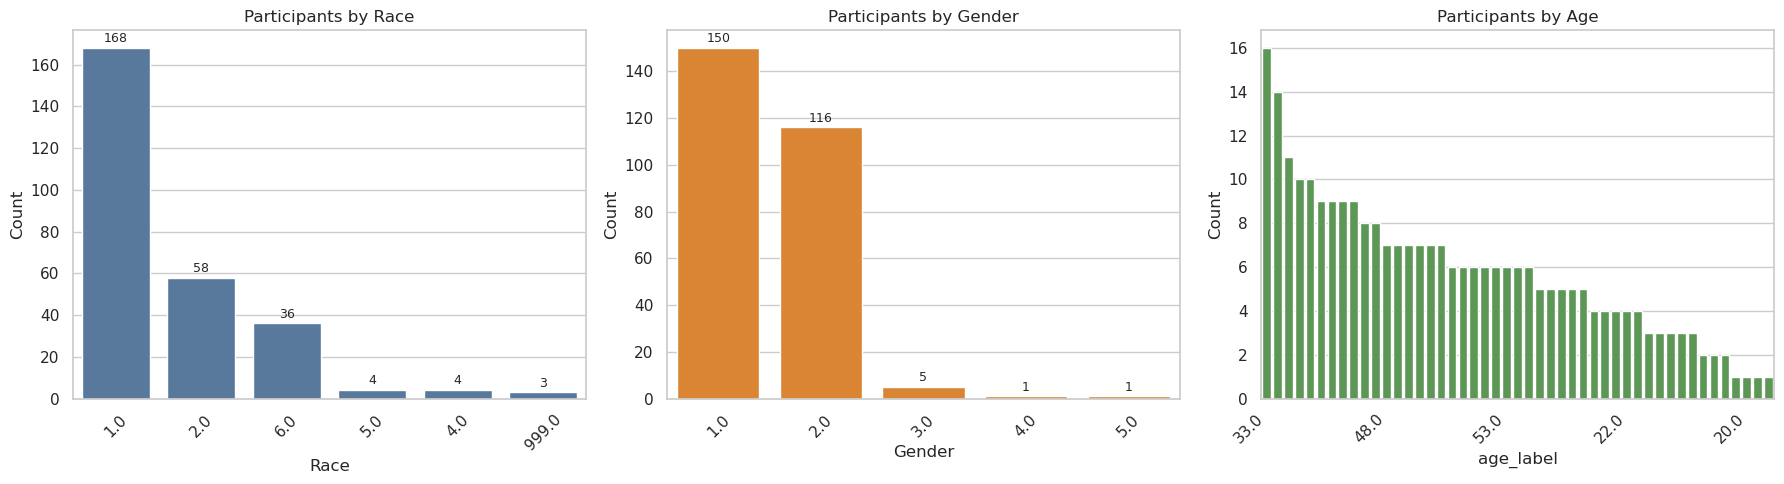

,Gender,Transcript Count,% of total transcripts,Participant Count,% of total participants,Transcripts per Participant
0,1.0,1403,49.1,150,54.9,9.35
1,2.0,1298,45.4,116,42.5,11.19
2,3.0,147,5.1,5,1.8,29.40
4,5.0,7,0.2,1,0.4,7.00
3,4.0,4,0.1,1,0.4,4.00


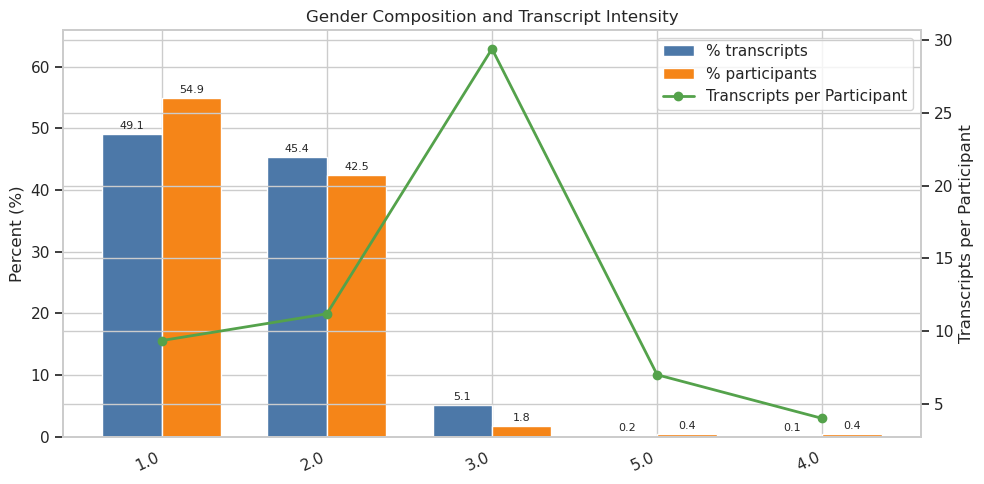

,Race,Transcript Count,Participant Count,% of total transcripts,% of total participants,Transcripts per Participant
0,1.0,1851,168,64.7,61.5,11.02
1,2.0,478,58,16.7,21.2,8.24
4,6.0,397,36,13.9,13.2,11.03
3,5.0,105,4,3.7,1.5,26.25
2,4.0,15,4,0.5,1.5,3.75


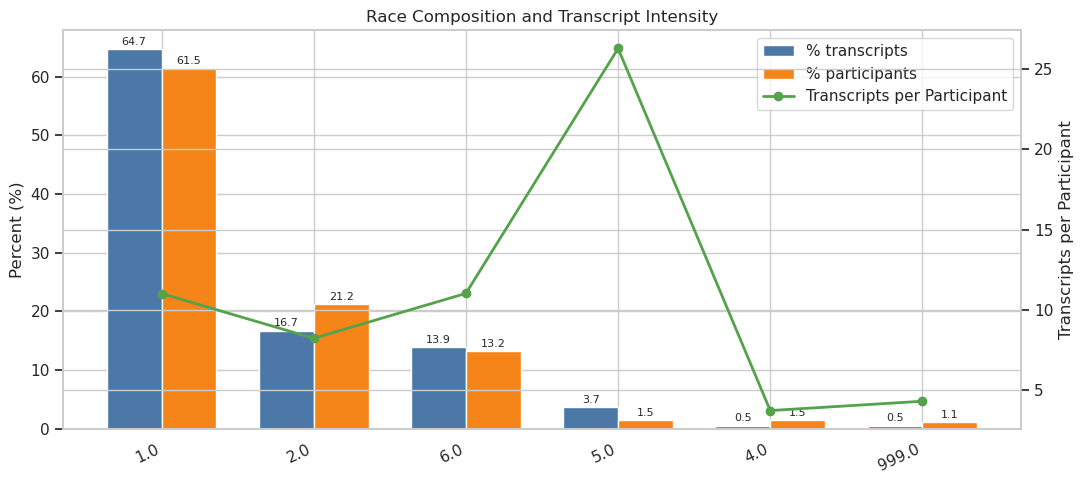

In [2]:
# --- Rollup transcripts to participant-level and summarize demographics ---
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1) Use location-encoded data (df first, file fallback)
if "location_encoded_df" in globals():
    transcript_df = location_encoded_df.copy()
elif "location_encoded_analysis_df" in globals():
    transcript_df = location_encoded_analysis_df.copy()
else:
    transcript_df = pd.read_csv(
        "/edata/obdw/sandwich_analysis_data/main_merged_sandwich_analysis_data.csv"
    ).copy()

print(f"Loaded transcript_df shape: {transcript_df.shape}")

# 2) Resolve likely column names
def pick_col(columns, candidates):
    for c in candidates:
        if c in columns:
            return c
    return None

pid_col = pick_col(transcript_df.columns, ["pid", "participant_id", "PID"])
race_col = pick_col(transcript_df.columns, ["race", "race_encoded", "race_cat"])
gender_col = pick_col(transcript_df.columns, ["gender", "gender_encoded", "sex"])
age_col = pick_col(transcript_df.columns, ["binned_age", "age_bin", "age_group", "age"])

required = {"pid": pid_col, "race": race_col, "gender": gender_col, "age": age_col}
missing = [k for k, v in required.items() if v is None]
if missing:
    raise ValueError(f"Missing required columns: {missing}. Found columns: {list(transcript_df.columns)}")

# 3) Participant-level rollup (one row per pid)
# Use first non-null value for each demographic field
def first_non_null(s):
    s = s.dropna()
    return s.iloc[0] if len(s) else pd.NA

participant_rollup = (
    transcript_df
    .groupby(pid_col, as_index=False)
    .agg({
        race_col: first_non_null,
        gender_col: first_non_null,
        age_col: first_non_null
    })
    .rename(columns={
        pid_col: "pid",
        race_col: "race",
        gender_col: "gender",
        age_col: "age"
    })
)

print(f"Transcript rows: {len(transcript_df):,}")
print(f"Unique participants (pid): {participant_rollup['pid'].nunique():,}")

# 4) Count tables
race_counts = participant_rollup["race"].value_counts(dropna=False).rename_axis("race").reset_index(name="n")
gender_counts = participant_rollup["gender"].value_counts(dropna=False).rename_axis("gender").reset_index(name="n")
age_counts = participant_rollup["age"].value_counts(dropna=False).rename_axis("age").reset_index(name="n")

display(race_counts, gender_counts, age_counts)

# 5) Optional decode labels if safe_decode exists
# 5) Decode labels robustly (works for raw coded values and already-decoded strings)
import pandas as pd

def decode_with_prefix(val, prefix):
    if pd.isna(val):
        return "Missing"

    s = str(val).strip()

    # If value already looks like text (not a numeric code), keep it
    if not s.replace(".", "", 1).isdigit():
        return s

    # Try common coded-key formats that safe_decode may expect
    candidates = [f"{prefix}_{s}"]
    try:
        f = float(s)
        candidates += [f"{prefix}_{f:.1f}", f"{prefix}_{int(f)}"]
    except Exception:
        pass

    # Fallback attempts
    candidates += [s, val]

    for c in candidates:
        try:
            out = safe_decode(c)
            # Accept only if decode changed the value meaningfully
            if out is not None and str(out).strip() not in {"", str(c)}:
                return str(out)
        except Exception:
            pass

    # Final fallback
    return s

plot_df = participant_rollup.copy()
plot_df["race_label"] = plot_df["race"].apply(lambda x: decode_with_prefix(x, "race"))
plot_df["gender_label"] = plot_df["gender"].apply(lambda x: decode_with_prefix(x, "gender"))
plot_df["age_label"] = plot_df["age"].apply(lambda x: decode_with_prefix(x, "age"))


# 6) Graphs (similar style: simple count bars)
sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=plot_df, x="race_label", order=plot_df["race_label"].value_counts().index, ax=axes[0], color="#4c78a8")
axes[0].set_title("Participants by Race")
axes[0].set_xlabel("Race")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

sns.countplot(data=plot_df, x="gender_label", order=plot_df["gender_label"].value_counts().index, ax=axes[1], color="#f58518")
axes[1].set_title("Participants by Gender")
axes[1].set_xlabel("Gender")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=45)

sns.countplot(
    data=plot_df,
    x="age_label",
    order=plot_df["age_label"].value_counts().index,
    ax=axes[2],
    color="#54a24b"
)
axes[2].set_title("Participants by Age")
axes[2].set_ylabel("Count")
#axes[2].set_xlabel("")  # remove x-axis label text
# keep only ~4 x tick labels visible
ticks = axes[2].get_xticks()
labels = [t.get_text() for t in axes[2].get_xticklabels()]
step = max(1, len(labels) // 4)

axes[2].set_xticks(ticks)
axes[2].set_xticklabels(
    [lab if i % step == 0 else "" for i, lab in enumerate(labels)],
    rotation=45, ha="right"
)

# Add bar labels
for i, ax in enumerate(axes):
    if i == 2:  # skip Participants by Age
        continue
    for c in ax.containers:
        ax.bar_label(c, fmt="%d", padding=2, fontsize=9)


plt.tight_layout()
plt.show()

# ToDo: delete, checking data integrity
# Gender summary with Count, % of total, and Transcript-per-Participant ratio
import pandas as pd
import numpy as np

# Optional: decode gender labels
def gender_label(x):
    try:
        return safe_decode(f"gender_{x}") if pd.notna(x) else "Missing"
    except Exception:
        return "Missing" if pd.isna(x) else str(x)

# 1) Transcript-level counts
t = (
    transcript_df.assign(Gender=transcript_df["gender"].apply(gender_label))
    .groupby("Gender", dropna=False)
    .size()
    .reset_index(name="Transcript Count")
)

# 2) Participant-level counts
p = (
    participant_rollup.assign(Gender=participant_rollup["gender"].apply(gender_label))
    .groupby("Gender", dropna=False)
    .size()
    .reset_index(name="Participant Count")
)

# Merge and compute requested metrics
gender_summary = t.merge(p, on="Gender", how="outer").fillna(0)
gender_summary["Transcript Count"] = gender_summary["Transcript Count"].astype(int)
gender_summary["Participant Count"] = gender_summary["Participant Count"].astype(int)

total_transcripts = gender_summary["Transcript Count"].sum()
total_participants = gender_summary["Participant Count"].sum()

gender_summary["% of total transcripts"] = (
    100 * gender_summary["Transcript Count"] / total_transcripts
).round(1)
gender_summary["% of total participants"] = (
    100 * gender_summary["Participant Count"] / total_participants
).round(1)

# Transcripts Count for each gender / Participant Count for each gender
gender_summary["Transcripts per Participant"] = np.where(
    gender_summary["Participant Count"] > 0,
    (gender_summary["Transcript Count"] / gender_summary["Participant Count"]).round(2),
    np.nan
)

# Final display columns
gender_summary = gender_summary[
    [
        "Gender",
        "Transcript Count",
        "% of total transcripts",
        "Participant Count",
        "% of total participants",
        "Transcripts per Participant",
    ]
].sort_values("Transcript Count", ascending=False)

display(gender_summary)

#ToDo: data check, possibly delete
import matplotlib.pyplot as plt
import numpy as np

# assumes your dataframe is named gender_summary
plot_df = gender_summary.copy()

# optional: shorten labels
plot_df["Gender_short"] = (
    plot_df["Gender"]
    .str.replace("Gender: ", "", regex=False)
    .str.replace("Transgender (M to F)", "Trans (M→F)", regex=False)
    .str.replace("Transgender (F to M)", "Trans (F→M)", regex=False)
)

x = np.arange(len(plot_df))
w = 0.36

fig, ax1 = plt.subplots(figsize=(10, 5))

# Bars for percentages
b1 = ax1.bar(
    x - w/2, plot_df["% of total transcripts"], width=w, label="% transcripts", color="#4c78a8"
)
b2 = ax1.bar(
    x + w/2, plot_df["% of total participants"], width=w, label="% participants", color="#f58518"
)

ax1.set_ylabel("Percent (%)")
ax1.set_ylim(0, max(plot_df["% of total transcripts"].max(), plot_df["% of total participants"].max()) * 1.2)
ax1.set_xticks(x)
ax1.set_xticklabels(plot_df["Gender_short"], rotation=25, ha="right")
ax1.set_title("Gender Composition and Transcript Intensity")

# Line for transcripts per participant
ax2 = ax1.twinx()
ax2.plot(
    x, plot_df["Transcripts per Participant"], color="#54a24b", marker="o", linewidth=2,
    label="Transcripts per Participant"
)
ax2.set_ylabel("Transcripts per Participant")

# Combined legend
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper right")

# Optional labels on bars
for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, h + 0.5, f"{h:.1f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

import pandas as pd
import numpy as np

# 1) Ensure transcript_df exists (set this to your source df if needed)
# transcript_df = analysis_df.copy()

# 2) Ensure participant_rollup exists
if "participant_rollup" not in globals():
    # pick likely column names
    pid_col = "pid" if "pid" in transcript_df.columns else "participant_id"
    race_col = "race" if "race" in transcript_df.columns else "race_encoded"

    def first_non_null(s):
        s = s.dropna()
        return s.iloc[0] if len(s) else pd.NA

    participant_rollup = (
        transcript_df.groupby(pid_col, as_index=False)
        .agg({race_col: first_non_null})
        .rename(columns={pid_col: "pid", race_col: "race"})
    )

# 3) Build race_summary
t = (
    transcript_df.assign(race=transcript_df["race"] if "race" in transcript_df.columns else transcript_df["race_encoded"])
    .groupby("race", dropna=False)
    .size()
    .reset_index(name="Transcript Count")
)

p = (
    participant_rollup.groupby("race", dropna=False)
    .size()
    .reset_index(name="Participant Count")
)

race_summary = t.merge(p, on="race", how="outer").fillna(0)
race_summary["Transcript Count"] = race_summary["Transcript Count"].astype(int)
race_summary["Participant Count"] = race_summary["Participant Count"].astype(int)

race_summary["% of total transcripts"] = (
    100 * race_summary["Transcript Count"] / race_summary["Transcript Count"].sum()
).round(1)
race_summary["% of total participants"] = (
    100 * race_summary["Participant Count"] / race_summary["Participant Count"].sum()
).round(1)
race_summary["Transcripts per Participant"] = np.where(
    race_summary["Participant Count"] > 0,
    (race_summary["Transcript Count"] / race_summary["Participant Count"]).round(2),
    np.nan
)

race_summary = race_summary.rename(columns={"race": "Race"}).sort_values("Transcript Count", ascending=False)
display(race_summary.head())

# Graph from race_summary (Composition + Transcript Intensity)
import matplotlib.pyplot as plt
import numpy as np

# Make sure race_summary exists
plot_df = race_summary.copy()

# Optional label cleanup
plot_df["Race_short"] = plot_df["Race"].astype(str).str.replace("Race: ", "", regex=False)

x = np.arange(len(plot_df))
w = 0.36

fig, ax1 = plt.subplots(figsize=(11, 5))

# Bars
bars1 = ax1.bar(
    x - w/2, plot_df["% of total transcripts"], width=w,
    color="#4c78a8", label="% transcripts"
)
bars2 = ax1.bar(
    x + w/2, plot_df["% of total participants"], width=w,
    color="#f58518", label="% participants"
)

ax1.set_title("Race Composition and Transcript Intensity")
ax1.set_ylabel("Percent (%)")
ax1.set_xticks(x)
ax1.set_xticklabels(plot_df["Race_short"], rotation=25, ha="right")

# Line on secondary axis
ax2 = ax1.twinx()
ax2.plot(
    x, plot_df["Transcripts per Participant"],
    color="#54a24b", marker="o", linewidth=2,
    label="Transcripts per Participant"
)
ax2.set_ylabel("Transcripts per Participant")

# Combined legend
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper right")

# Optional bar labels
for bars in [bars1, bars2]:
    for b in bars:
        h = b.get_height()
        ax1.text(b.get_x() + b.get_width()/2, h + 0.4, f"{h:.1f}",
                 ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()
